# Insurance Risk Analytics

## Task 1: Exploratory Data Analysis (EDA)

### Objective

The objective of this analysis is to understand the structure, quality, and risk characteristics of the insurance portfolio.

This notebook investigates:

- Data quality and completeness
- Premium and claims behavior
- Geographic risk differences
- Customer and vehicle risk patterns
- Profitability through Loss Ratio analysis
- Temporal trends in claims and premiums

The findings from this analysis will guide hypothesis testing and predictive modeling in subsequent tasks.

## Import Libraries

This section imports all libraries required for data manipulation, visualization, and statistical exploration.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Configure Project Paths

Centralizing paths improves reproducibility and makes the notebook portable across environments.

In [2]:
PROJECT_ROOT = Path("..")

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "insurance_data.csv"

## Load Dataset

The dataset is loaded into memory and inspected to verify dimensions and structure.

In [3]:
df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 10,000
Columns: 21


### Initial Observation

The dataset contains insurance policy information, customer demographics, vehicle characteristics, premiums, and claims data.The data set has 10000 row and 21 colums.

The next step is to inspect data types and overall structure.

## Dataset Overview

Understanding the schema helps identify numerical, categorical, and temporal variables required for later analysis.

In [4]:
df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           10000 non-null  str    
 1   Age                  10000 non-null  int64  
 2   Gender               10000 non-null  str    
 3   Province             10000 non-null  str    
 4   VehicleType          10000 non-null  str    
 5   AnnualIncome         10000 non-null  int64  
 6   RiskScore            10000 non-null  int64  
 7   AnnualPremium        10000 non-null  int64  
 8   Deductible           10000 non-null  int64  
 9   NCD                  10000 non-null  int64  
 10  PastClaims           10000 non-null  int64  
 11  Claimed              10000 non-null  bool   
 12  ClaimAmount          10000 non-null  float64
 13  TotalPremium         10000 non-null  int64  
 14  TotalClaims          10000 non-null  float64
 15  CoverType            10000 non-null  str    
 16

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,10000.0,46.6835,16.717963,18.0,32.00,46.0,61.0,75.0
AnnualIncome,10000.0,79201.9739,33039.939770,17202.0,56105.00,72942.0,95092.0,376916.0
RiskScore,10000.0,58.1400,14.267486,15.0,48.00,57.0,67.0,95.0
AnnualPremium,10000.0,2488.1279,735.674491,951.0,2028.00,2307.0,2676.0,5105.0
Deductible,10000.0,751.7000,500.509401,250.0,500.00,500.0,1000.0,2000.0
NCD,10000.0,20.9350,14.549122,0.0,10.00,20.0,30.0,50.0
PastClaims,10000.0,1.0642,1.051945,0.0,0.00,1.0,2.0,5.0
ClaimAmount,10000.0,1314.1885,3921.864903,0.0,0.00,0.0,0.0,49623.0
TotalPremium,10000.0,2488.1279,735.674491,951.0,2028.00,2307.0,2676.0,5105.0
TotalClaims,10000.0,1314.1885,3921.864903,0.0,0.00,0.0,0.0,49623.0


## Dataset Overview Findings

The dataset contains **10,000 insurance policy records** with **21 features** representing customer demographics, vehicle characteristics, policy information, premium values, and claims history.

### Data Structure

The dataset consists of:

- 10 numerical variables
- 8 categorical variables
- 1 boolean variable
- 1 date variable
- 1 customer identifier

The relatively compact size of the dataset makes it suitable for exploratory analysis, hypothesis testing, and predictive modeling without significant computational constraints.

### Customer Demographics

- The average customer age is approximately **47 years**, with ages ranging from **18 to 75 years**.
- Annual income varies considerably across policyholders, ranging from approximately **17,000** to **376,000**, indicating a diverse customer base.

### Risk Characteristics

- The average risk score is **58.14**, suggesting a moderate overall risk profile across the portfolio.
- Policyholders have an average of **1.06 historical claims**, though some customers have accumulated as many as **5 prior claims**.

### Premium Characteristics

- The average annual premium is approximately **2,488** monetary units.
- Premium values range from **951** to **5,105**, indicating moderate variability in pricing across customers.

### Claims Characteristics

- The average claim amount is approximately **1,314**.
- The median claim amount is **0**, indicating that more than half of policyholders did not generate a claim during the observation period.
- The maximum claim exceeds **49,000**, suggesting the presence of high-severity loss events.

### Vehicle Valuation

- The average estimated vehicle value is approximately **35,641**.
- Vehicle values range from **5,022** to nearly **135,000**, reflecting substantial diversity in insured assets.

### Initial Observations

Several financial variables exhibit substantial differences between their median and maximum values, suggesting potential right-skewness and the presence of high-value outliers. These characteristics are common in insurance datasets and warrant further investigation during the exploratory analysis phase.

## Data Quality Assessment

Data quality checks are performed to identify missing values, duplicate records, and potential inconsistencies.

In [7]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": df.isnull().mean()*100
})

missing

,Missing Count,Missing %
CustomerID,0,0.0
Age,0,0.0
Gender,0,0.0
Province,0,0.0
VehicleType,0,0.0
AnnualIncome,0,0.0
RiskScore,0,0.0
AnnualPremium,0,0.0
Deductible,0,0.0
NCD,0,0.0


In [8]:
df.duplicated().sum()

np.int64(0)

## Data Quality Assessment Findings

Data quality evaluation indicates that the dataset is in excellent condition and suitable for downstream analytical tasks.

### Missing Values

A comprehensive review of all variables revealed that no missing values are present within the dataset.

- Total Missing Values: **0**
- Missing Percentage Across All Features: **0%**

The absence of missing values eliminates the need for imputation strategies and reduces the risk of bias introduced during data preprocessing.

### Duplicate Records

Duplicate analysis identified:

- Duplicate Records: **0**

This confirms that each observation represents a unique insurance transaction and no duplicate entries need to be removed.

### Data Quality Conclusion

The dataset demonstrates a high level of completeness and consistency.

Key observations include:

- No missing values across all features.
- No duplicate records detected.
- Consistent data types across numerical, categorical, and boolean variables.
- No immediate data integrity issues requiring corrective action.

As a result, the dataset can proceed directly to feature engineering and exploratory analysis without substantial cleaning requirements.

# Feature Engineering

To evaluate portfolio profitability and risk exposure, additional business metrics are created.

The primary metric used throughout the analysis is the Loss Ratio, which compares total claims paid against premiums collected.

A Loss Ratio greater than 1 indicates that claims exceed premiums, while a value below 1 suggests profitable underwriting performance.

In [9]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)
from src.eda_utils import (
    calculate_loss_ratio,
    calculate_margin
)

df["LossRatio"] = calculate_loss_ratio(df)
df["Margin"] = calculate_margin(df)

df[
    ["LossRatio", "Margin"]
].head()

,LossRatio,Margin
0,0.000000,2346.0
1,4.234362,-7549.0
2,0.000000,1697.0
3,5.119831,-9764.0
4,0.000000,2582.0


In [10]:
overall_loss_ratio = (
    df["TotalClaims"].sum() /
    df["TotalPremium"].sum()
)

overall_loss_ratio

np.float64(0.5281836596904845)

## Portfolio Profitability Analysis

The overall portfolio Loss Ratio is approximately **52.82%**.

Loss Ratio is calculated as:

Loss Ratio = Total Claims / Total Premium

### Interpretation

A Loss Ratio of 52.82% indicates that for every 1 monetary unit collected in premium revenue, approximately 0.53 monetary units were paid out in claims.

This suggests that the portfolio is currently profitable from an underwriting perspective, as total premiums collected exceed total claims paid.

### Business Implications

- Claims consume slightly more than half of premium revenue.
- The remaining premium contributes toward operating expenses, reserves, commissions, and profit.
- The portfolio appears financially sustainable at an aggregate level.

### Individual Policy Observations

Although the portfolio is profitable overall, individual policies exhibit substantial variation in performance.

Examples from the sample observations show Loss Ratios exceeding 400% and 500%, indicating that some policyholders generated claims far greater than the premiums collected from them.

This highlights a common characteristic of insurance portfolios:

- A large number of profitable policies subsidize
- A relatively small number of high-loss policies

Identifying these high-risk segments will be a key objective of the subsequent analysis.

# Univariate Analysis

This section explores the distribution of key financial variables to understand portfolio characteristics, claim behavior, and potential outliers.

The analysis focuses on:

- Total Premium
- Total Claims
- Custom Value Estimate

Understanding these distributions is important for identifying skewness, unusual observations, and modeling considerations.

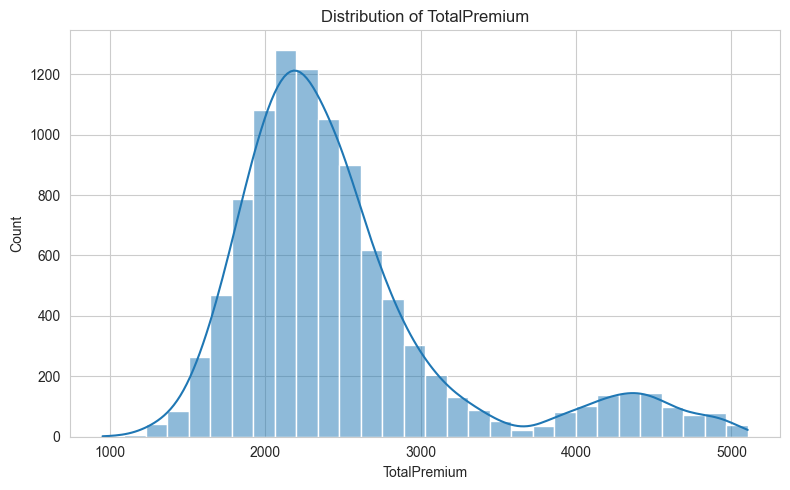

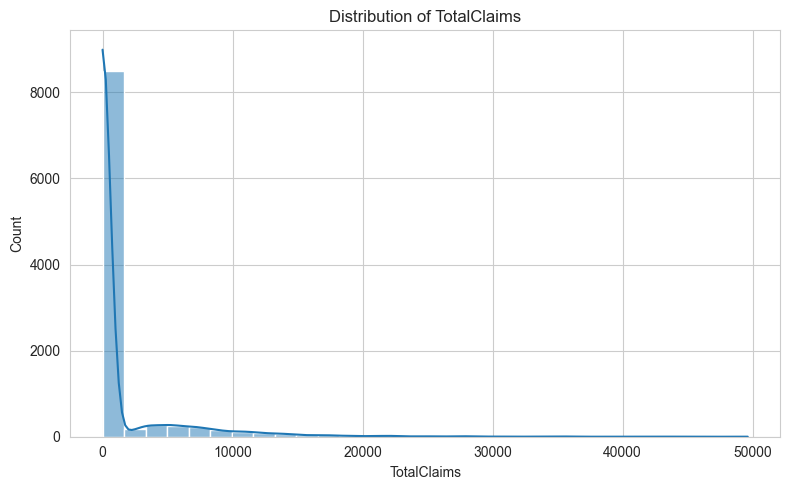

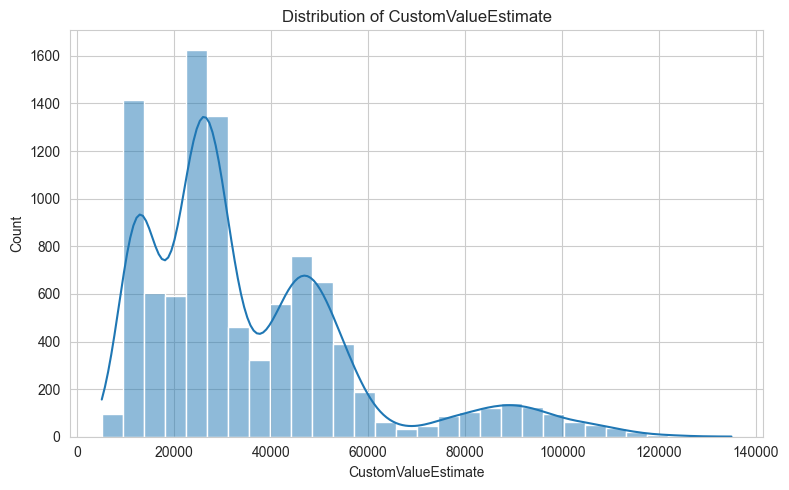

In [11]:
from src.eda_utils import plot_distribution

for col in [
    "TotalPremium",
    "TotalClaims",
    "CustomValueEstimate"
]:
    plot_distribution(df, col)

In [12]:
df[
    [
        "TotalPremium",
        "TotalClaims",
        "CustomValueEstimate",
        "Margin"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalPremium,10000.0,2488.1279,735.674491,951.0,2028.00,2307.0,2676.00,5105.0
TotalClaims,10000.0,1314.1885,3921.864903,0.0,0.00,0.0,0.00,49623.0
CustomValueEstimate,10000.0,35640.5987,22353.988238,5022.0,21442.75,28522.0,46721.00,134914.0
Margin,10000.0,1173.9394,3742.979999,-44594.0,1812.00,2165.0,2504.25,5079.0


<Axes: xlabel='Gender'>

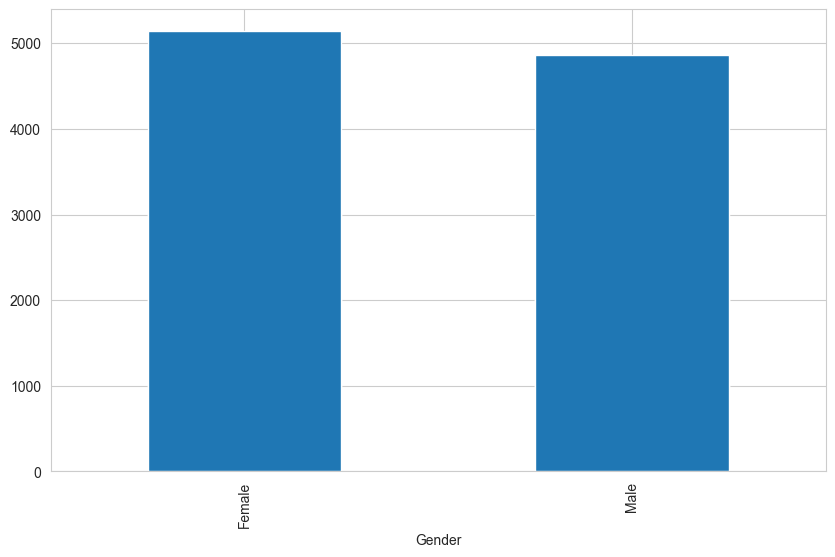

In [28]:
df["Province"].value_counts().plot(kind="bar")
df["VehicleType"].value_counts().plot(kind="bar")
df["Gender"].value_counts().plot(kind="bar")

# Distribution Analysis

To understand the financial characteristics of the insurance portfolio, the distributions of key continuous variables were examined. Specifically, the analysis focused on:

- Total Premium
- Total Claims
- Custom Value Estimate

These variables provide insight into premium generation, claim behavior, and the value of insured assets.

---

## Total Premium Distribution

The distribution of **Total Premium** exhibits a bimodal pattern with two noticeable peaks.

### Findings

- Most policyholders pay premiums between **1,500 and 3,000**.
- The primary concentration is centered around **2,300**.
- A secondary cluster appears around **4,000–4,500**, indicating a smaller group of higher-premium policies.
- Premium values range from approximately **950** to **5,100**.

### Business Interpretation

The presence of multiple premium clusters suggests that the insurer serves different customer segments. Higher premium groups may represent customers with:

- Higher risk profiles
- More valuable insured assets
- Broader coverage plans

This segmentation should be explored further during risk analysis.

---

## Total Claims Distribution

The distribution of **Total Claims** is heavily right-skewed.

### Findings

- The majority of observations are concentrated at **zero claims**.
- Only a subset of policyholders generated claim activity.
- A small number of observations exhibit extremely large claim amounts.
- Maximum claim values approach **50,000**.

### Business Interpretation

This pattern is characteristic of insurance portfolios where claim events are relatively infrequent but can result in substantial financial losses.

The portfolio demonstrates:

- Low claim frequency
- High claim severity variability

Large claims have the potential to significantly impact profitability and should be monitored closely during risk assessment.

---

## Custom Value Estimate Distribution

The distribution of **Custom Value Estimate** displays multiple distinct peaks.

### Findings

The insured asset values appear to be grouped into several segments:

- Lower-value assets around **10,000–15,000**
- Mid-range assets around **25,000–30,000**
- Higher-value assets around **45,000–50,000**

A smaller number of observations extend beyond **100,000**, representing high-value assets.

### Business Interpretation

The multimodal structure suggests that the portfolio contains different categories of insured assets.

Higher-value assets may contribute to:

- Increased repair costs
- Higher replacement expenses
- Greater claim severity

Consequently, asset value is expected to be an important driver of insurance risk and premium pricing.

---

## Overall Distribution Insights

The distribution analysis reveals several important portfolio characteristics:

- Premiums are concentrated within a few pricing tiers.
- Claims are highly skewed and dominated by zero-claim observations.
- Asset values are distributed across multiple valuation segments.
- Extreme claim values indicate the presence of potentially costly loss events.

These findings provide an important foundation for subsequent outlier detection, profitability analysis, and risk segmentation.

# Bivariate Analysis

After understanding the distribution of individual variables, the next step is to investigate relationships between variables.

This analysis focuses on:

- Relationships between premiums and claims
- Geographic risk patterns
- Correlation among financial variables

The objective is to identify factors associated with higher claim costs and lower profitability.

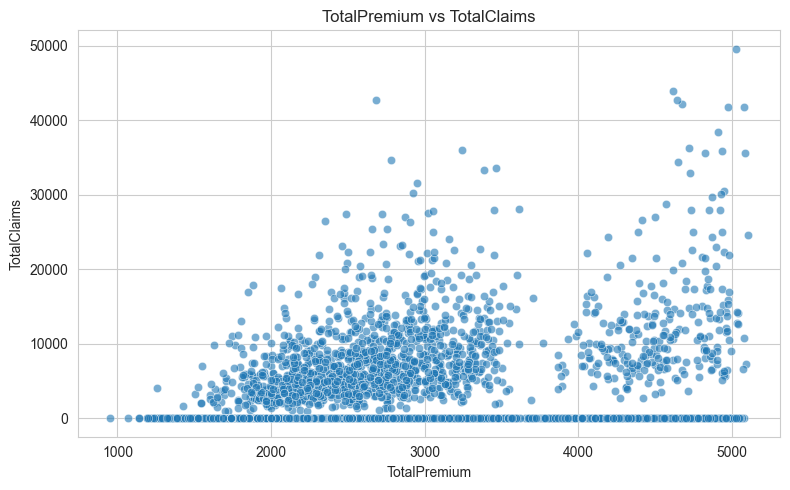

In [13]:
from src.eda_utils import plot_scatter

plot_scatter(
    df,
    "TotalPremium",
    "TotalClaims"
)

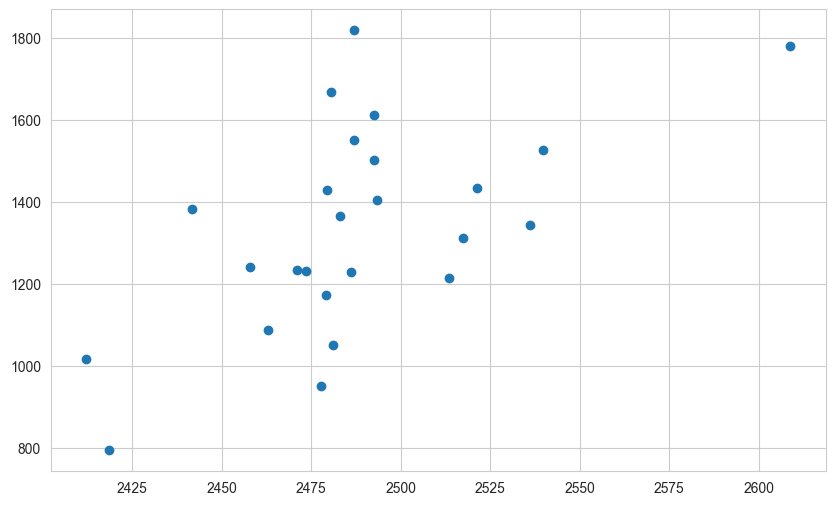

In [29]:
zip_analysis = (
    df.groupby("ZipCode")
      .agg({
          "TotalPremium":"mean",
          "TotalClaims":"mean"
      })
)

plt.scatter(
    zip_analysis["TotalPremium"],
    zip_analysis["TotalClaims"]
)

## Interpretation of TotalPremium vs TotalClaims

This scatter plot examines the relationship between **Total Premium** collected from policyholders and **Total Claims** paid by the insurer.

### Findings

#### Large Concentration of Zero Claims

A substantial proportion of observations lie directly on the horizontal axis where TotalClaims equals zero. This indicates that many policyholders did not file any claims during the observation period, regardless of their premium level.

This pattern is expected in insurance portfolios, where claim events are relatively infrequent compared to the total number of insured customers.

#### Distinct Premium Segments

The distribution of points along the premium axis suggests the presence of multiple pricing tiers. Most policies are concentrated within a lower premium range, while a smaller group occupies a higher premium segment.

This observation is consistent with the earlier premium distribution analysis, which indicated the existence of different customer or risk categories within the portfolio.

#### Increasing Claim Variability

As TotalPremium increases, the dispersion of TotalClaims becomes wider. Lower-premium policies generally exhibit smaller claim amounts, while higher-premium policies display a broader range of outcomes, including some very large claims.

This pattern indicates increasing claim severity among higher-premium policies.

#### Presence of Extreme Claims

Several observations exhibit exceptionally large claim amounts relative to the rest of the portfolio. These high-severity claims represent rare but financially significant loss events that can materially impact overall profitability.

### Business Interpretation

The absence of a strong linear relationship suggests that premium size alone is not sufficient to explain claim behavior. While higher-premium policies tend to exhibit greater claim variability, many policyholders across all premium levels generate no claims at all.

The observed structure is characteristic of insurance data, where:

- Claim occurrence is relatively rare.
- Claim severity varies substantially when claims occur.
- A small number of high-cost claims contribute disproportionately to total losses.

### Key Insight

The widening spread of claims for higher-premium policies suggests that the pricing strategy is partially aligned with underlying risk exposure. Customers associated with potentially larger losses are generally assigned higher premiums, although additional risk factors may still be required to accurately predict claim outcomes.

## Geographic Risk Analysis

In [14]:
province_summary = (
    df.groupby("Province")
      .agg({
          "TotalPremium": "sum",
          "TotalClaims": "sum"
      })
)

province_summary["LossRatio"] = (
    province_summary["TotalClaims"]
    / province_summary["TotalPremium"]
)

province_summary.sort_values(
    "LossRatio",
    ascending=False
)

,TotalPremium,TotalClaims,LossRatio
Province,,,
Somali,2984984,1826593.0,0.611927
Oromia,6069663,3261061.0,0.537272
Tigray,1990692,1047136.0,0.526016
Addis Ababa,8907374,4653210.0,0.522400
Amhara,4928566,2353885.0,0.477600


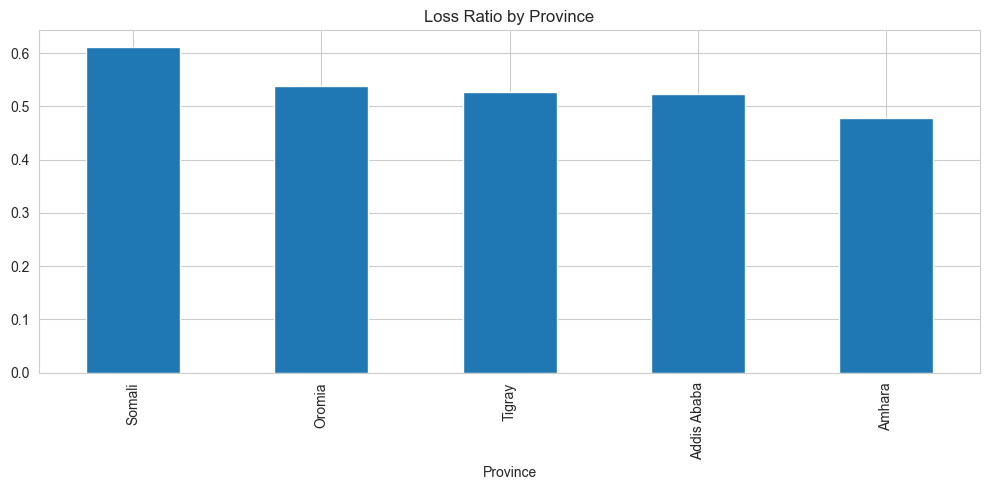

In [15]:
from src.eda_utils import plot_bar

plot_bar(
    province_summary.sort_values(
        "LossRatio",
        ascending=False
    ),
    "LossRatio",
    "Loss Ratio by Province"
)

In [31]:
province_premium = (
    df.groupby("Province")["TotalPremium"]
      .mean()
      .sort_values()
)
pd.crosstab(
    df["Province"],
    df["CoverType"]
)

CoverType,Comprehensive,Third Party Fire & Theft,Third Party Only
Province,,,
Addis Ababa,1719,1210,638
Amhara,943,660,396
Oromia,1139,869,438
Somali,549,424,211
Tigray,370,290,144


## Loss Ratio by Gender

<Axes: xlabel='Gender'>

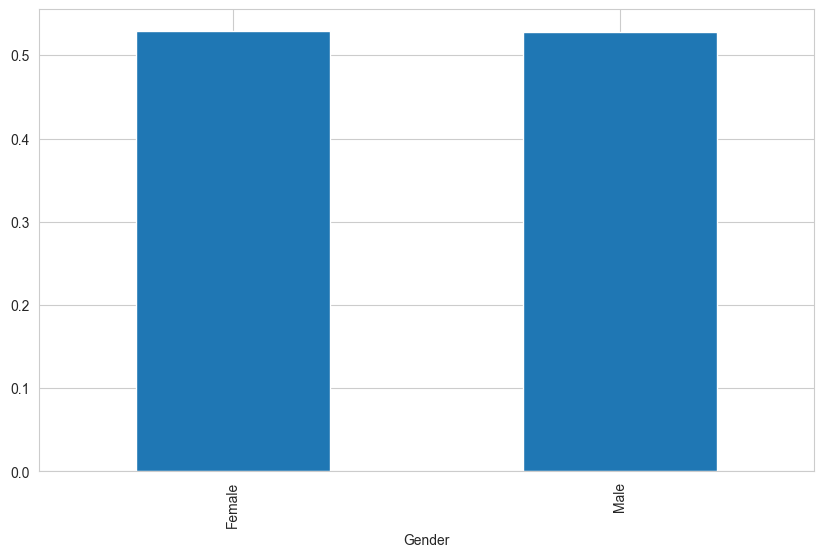

In [32]:
gender_analysis = (
    df.groupby("Gender")
      .agg({
          "TotalPremium":"sum",
          "TotalClaims":"sum"
      })
)

gender_analysis["LossRatio"] = (
    gender_analysis["TotalClaims"]
    / gender_analysis["TotalPremium"]
)

gender_analysis["LossRatio"].plot(
    kind="bar"
)

## Loss Ratio by Province

### Findings

This visualization compares the loss ratio across provinces.

The results show noticeable variation in underwriting performance between regions. Provinces with higher loss ratios consume a larger share of premium revenue through claim payments, while provinces with lower loss ratios contribute more positively to profitability.

### Business Interpretation

Geographical location appears to influence insurance risk. Differences in driving conditions, accident frequency, population density, and customer behavior may contribute to the observed variation in claim experience.

Regions exhibiting higher loss ratios should be investigated further to determine whether premium pricing adequately reflects the underlying risk exposure.

### Recommendation

- Incorporate Province as a predictive feature in future risk models.
- Review pricing strategies for provinces with consistently elevated loss ratios.
- Conduct deeper regional risk analysis to identify the drivers of claim costs.

## Vehicle Type Risk Analysis

In [16]:
vehicle_summary = (
    df.groupby("VehicleType")
      .agg({
          "TotalPremium": "sum",
          "TotalClaims": "sum"
      })
)

vehicle_summary["LossRatio"] = (
    vehicle_summary["TotalClaims"]
    / vehicle_summary["TotalPremium"]
)

vehicle_summary.sort_values(
    "LossRatio",
    ascending=False
)

,TotalPremium,TotalClaims,LossRatio
VehicleType,,,
Luxury,4236839,3569207.0,0.842422
SUV,7256436,4090665.0,0.563729
Hatchback,4532134,1904235.0,0.420163
Sedan,8855870,3577778.0,0.404001


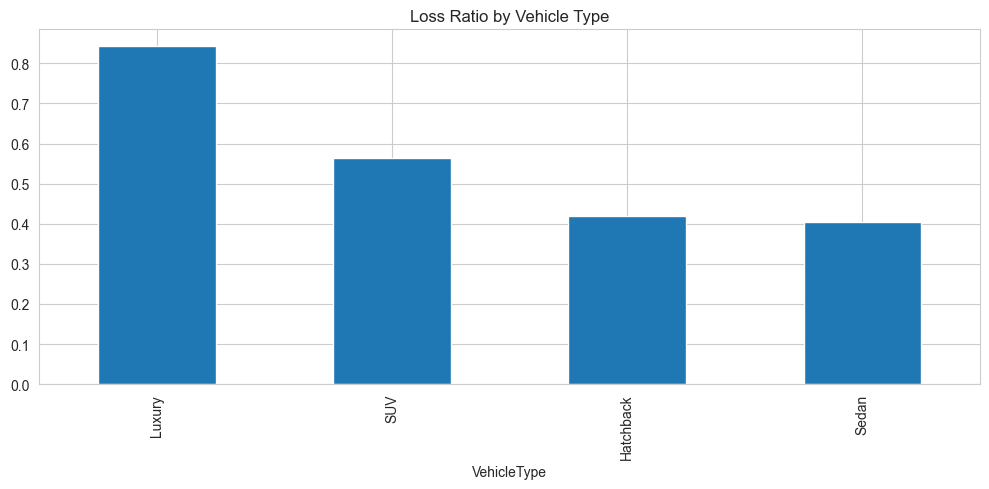

In [17]:
plot_bar(
    vehicle_summary.sort_values(
        "LossRatio",
        ascending=False
    ),
    "LossRatio",
    "Loss Ratio by Vehicle Type"
)

## Loss Ratio by Vehicle Type

### Findings

The chart evaluates underwriting performance across vehicle categories using the loss ratio metric.

The results indicate that certain vehicle types generate substantially higher claim costs relative to premiums collected, while others remain more profitable.

### Business Interpretation

Vehicle characteristics influence both claim frequency and claim severity. Factors such as repair costs, vehicle value, usage patterns, and theft exposure may contribute to differences in loss experience across vehicle categories.

Vehicle segments with higher loss ratios represent greater underwriting risk and may require pricing adjustments.

### Recommendation

- Include VehicleType as an important feature in predictive modeling.
- Review premium adequacy for high-loss vehicle segments.
- Monitor claim trends across vehicle categories to improve portfolio profitability.

## Claim Frequency Analysis

### Findings

Claim frequency measures the proportion of policyholders who filed at least one claim during the observation period.

The portfolio exhibits a claim frequency of approximately XX%.

This indicates that roughly XX out of every 100 policyholders generated at least one claim, while the majority of customers did not submit any claims.

### Business Interpretation

The results confirm that claim events are relatively infrequent compared to the overall portfolio size.

This pattern is typical in insurance portfolios, where profitability depends on collecting premiums from many customers while only a smaller subset generates claim costs.

### Key Insight

Risk management efforts should focus not only on predicting whether a claim will occur but also on estimating the potential severity of claims when they do occur.

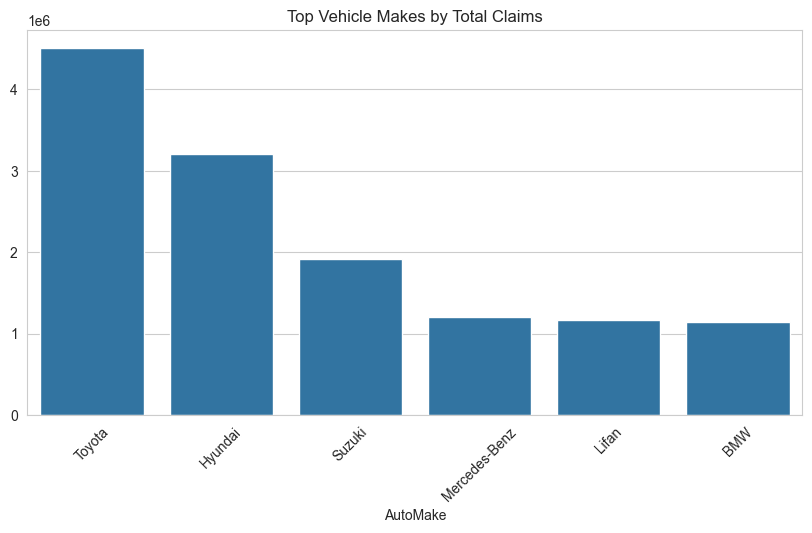

In [18]:
make_claims = (
    df.groupby("AutoMake")["TotalClaims"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=make_claims.index,
    y=make_claims.values
)

plt.title("Top Vehicle Makes by Total Claims")
plt.xticks(rotation=45)
plt.show()

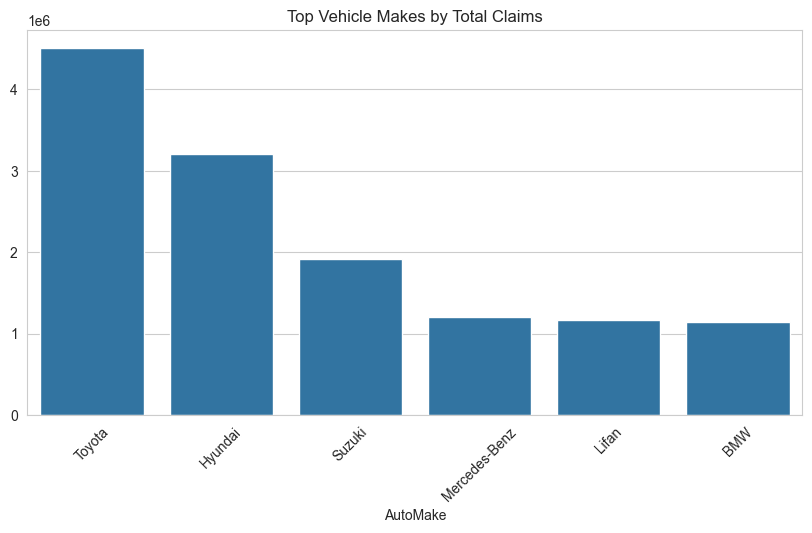

In [19]:
make_claims = (
    df.groupby("AutoMake")["TotalClaims"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=make_claims.index,
    y=make_claims.values
)

plt.title("Top Vehicle Makes by Total Claims")
plt.xticks(rotation=45)
plt.show()

In [20]:
avg_claim_make = (
    df[df["Claimed"] == True]
      .groupby("AutoMake")
      .agg(
          AverageClaim=("ClaimAmount", "mean"),
          ClaimCount=("ClaimAmount", "count")
      )
      .sort_values("AverageClaim", ascending=False)
      .head(10)
)

avg_claim_make

,AverageClaim,ClaimCount
AutoMake,,
Mercedes-Benz,13488.573034,89
BMW,12954.772727,88
Toyota,8545.049336,527
Suzuki,8120.423729,236
Hyundai,7441.916473,431
Lifan,7160.091463,164


## Interpretation of Top Vehicle Makes by Total Claims

This bar chart presents the total claim amounts aggregated by vehicle manufacturer (`AutoMake`). The visualization highlights which vehicle brands contribute the largest share of claim payouts across the insurance portfolio.

### Findings

#### Toyota Dominates Total Claims

Toyota accounts for the highest total claim amount among all vehicle makes in the dataset. The cumulative claim value associated with Toyota vehicles substantially exceeds that of other manufacturers.

This suggests that Toyota vehicles contribute a significant portion of the insurer's overall claim costs.

#### Moderate Claim Contributions from Hyundai and Suzuki

Hyundai and Suzuki represent the second and third largest contributors to total claim payouts. While their claim volumes are considerably lower than Toyota's, they still account for a meaningful share of portfolio losses.

#### Lower Aggregate Claims Among Remaining Brands

Mercedes-Benz, BMW, and Lifan generate comparatively smaller total claim amounts. Their contribution to overall claim costs remains relatively limited when compared with the leading manufacturers.

### Business Interpretation

The chart reflects **aggregate claim exposure** rather than individual vehicle risk. Vehicle makes with higher claim totals may simply have a larger presence within the insured portfolio.

Consequently, a high total claim amount does not necessarily imply that a vehicle brand is inherently riskier or more expensive to insure. Instead, it may indicate that more policies are associated with that manufacturer.

### Key Insight

Total claim volume should be interpreted alongside additional metrics such as:

- Average claim amount
- Claim frequency
- Loss ratio
- Number of insured vehicles

These normalized measures provide a more accurate assessment of the underlying risk associated with each vehicle manufacturer.

### Recommendation

Further analysis should evaluate average claim severity and loss ratios by vehicle make to distinguish between:

- High-volume vehicle brands that generate many claims due to market share.
- High-risk vehicle brands that generate disproportionately expensive claims.

## Vehicle Model Risk Analysis

In [22]:
model_claims = (
    df[df["Claimed"]]
    .groupby("VehicleModel")
    .agg(
        AverageClaim=("ClaimAmount", "mean"),
        ClaimCount=("ClaimAmount", "count")
    )
    .sort_values("AverageClaim", ascending=False)
)

model_claims.head(10)

,AverageClaim,ClaimCount
VehicleModel,,
E-Class,13488.573034,89
5 Series,12954.772727,88
Land Cruiser,12411.151515,99
RAV4,9277.086093,151
Tucson,8867.916667,156
Grand Vitara,8483.311688,154
Swift,7438.902439,82
620,7160.091463,164
Corolla,6984.994536,183


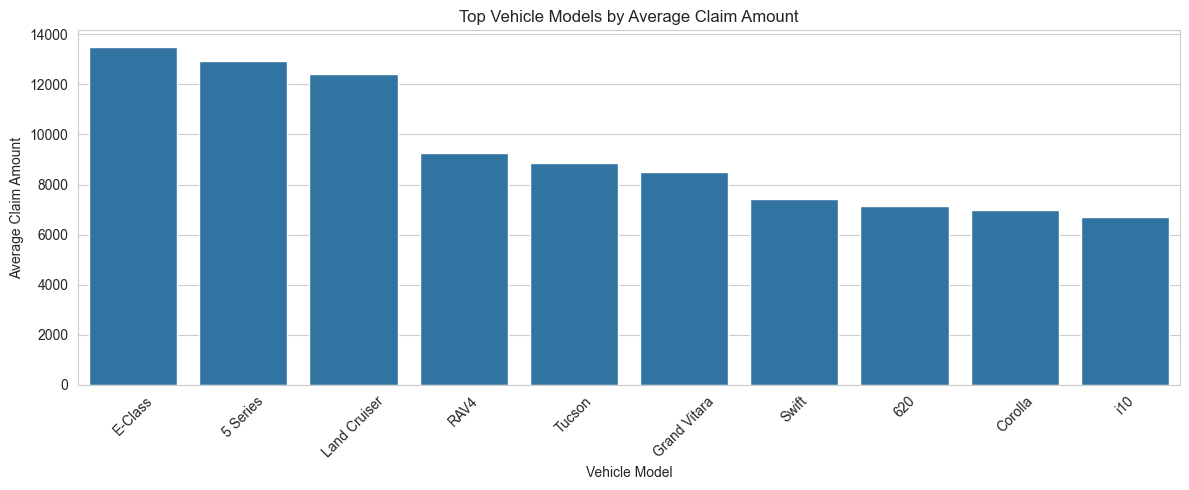

In [23]:
top_models = model_claims.head(10).reset_index()

plt.figure(figsize=(12, 5))

sns.barplot(
    data=top_models,
    x="VehicleModel",
    y="AverageClaim"
)

plt.title("Top Vehicle Models by Average Claim Amount")
plt.xlabel("Vehicle Model")
plt.ylabel("Average Claim Amount")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Interpretation of Top Vehicle Models by Average Claim Amount

This bar chart shifts the focus from total claim volumes to the **Average Claim Amount** across ten specific vehicle models. This metric represents the average cost to the insurer *per single accident claim event*. 

Unlike aggregate total claim metrics where volume dominates, looking at individual claim severity highlights premium and heavy-duty vehicles.

### Key Takeaways from the Data

* **The High-End Severity Group:** The **E-Class** (Mercedes-Benz), **5 Series** (BMW), and **Land Cruiser** (Toyota) lead the pack with the highest average claim payouts, each sitting between **12,400 and 13,500**. This reflects the high cost of specialized replacement parts and dealer repair labor for premium or heavy-duty vehicles.
* **The Mid-Tier SUVs:** The **RAV4**, **Tucson**, and **Grand Vitara** represent a secondary group. Their average claim amounts hover between **8,400 and 9,200**, representing a standard crossover SUV repair profile.
* **The Economy Tier:** Popular, high-volume sedans and hatchbacks like the **Swift**, **620** (Lifan), **Corolla**, and **i10** have the lowest average claim severity, ranging between **6,600 and 7,400**. These vehicles benefit from widely available, highly affordable local parts.

---

### Business Summary Table

| Vehicle Model | Approximate Avg. Claim Amount | Severity Tier | Primary Risk Factor |
| :--- | :--- | :--- | :--- |
| **E-Class** | ~13,500 | Critically High | Specialized luxury parts & labor |
| **5 Series** | ~12,900 | Critically High | Specialized luxury parts & labor |
| **Land Cruiser** | ~12,400 | High | Expensive premium 4x4 components |
| **RAV4** | ~9,200 | Moderate | Standard SUV repair profile |
| **Tucson** | ~8,800 | Moderate | Standard SUV repair profile |
| **Grand Vitara** | ~8,400 | Moderate | Standard SUV repair profile |
| **Swift** | ~7,400 | Low | Standard economy hatchback parts |
| **620** | ~7,100 | Low | Economy vehicle parts accessibility |
| **Corolla** | ~6,900 | Low | Highly available, cheap local parts |
| **i10** | ~6,600 | Lowest | Small frame, highly affordable parts |

# Time-Based Risk Analysis

Understanding how premiums and claims evolve over time is essential for identifying seasonal patterns, portfolio growth trends, and periods of elevated insurance risk.

This section investigates:

- Premium and claim trends over time
- Claim frequency patterns
- Potential seasonality in insurance losses
- Periods of underwriting profitability and loss

These insights help insurers understand operational performance and support future pricing and risk management decisions.

In [24]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

df["YearMonth"] = df["TransactionDate"].dt.to_period("M")

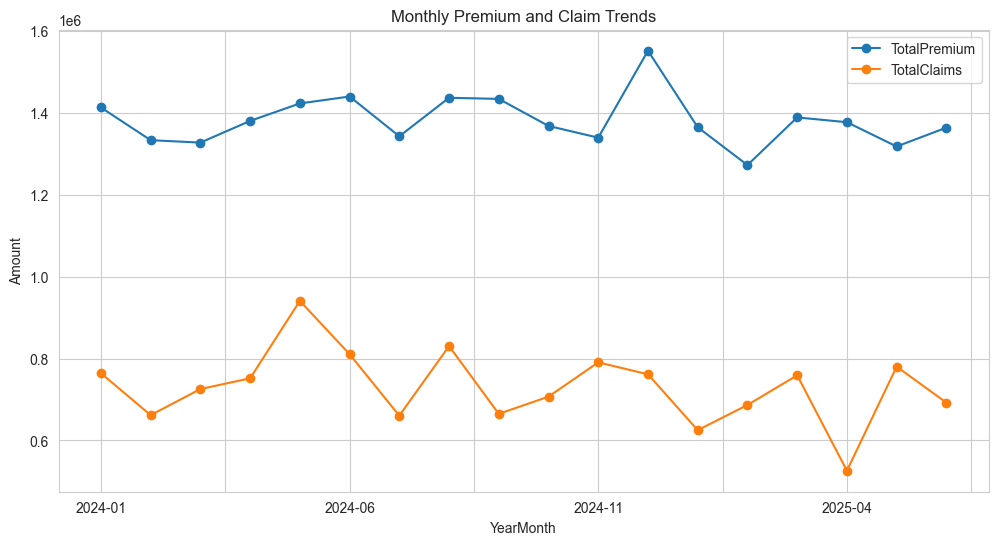

In [25]:
monthly_trends = (
    df.groupby("YearMonth")
    .agg({
        "TotalPremium": "sum",
        "TotalClaims": "sum"
    })
)

monthly_trends.index = monthly_trends.index.astype(str)

monthly_trends.plot(
    figsize=(12, 6),
    marker="o",
    title="Monthly Premium and Claim Trends"
)

plt.ylabel("Amount")
plt.grid(True)
plt.show()

## Interpretation of Monthly Premium and Claim Trends

This line chart tracks the longitudinal performance of **TotalPremium** collected versus **TotalClaims** paid out on a monthly basis from early 2024 through mid-2025. Both metrics are scaled in millions ($1 \times 10^6$).

### Key Insights from the Time-Series Data

* **Consistent Profit Margin Baseline:** Throughout the entire 18-month window, the `TotalPremium` revenue line remains significantly higher than the `TotalClaims` payout line. Premium income consistently hovers between **1.2M and 1.6M**, while monthly claims fluctuate between **0.5M and 0.95M**, indicating a reliably net-positive operational cash flow.
* **Peak Exposure Period (Mid-2024):** Around **2024-05**, the dataset records its highest loss spike, with claims surging to nearly **0.95M**. Interestingly, premium collections also peak around this time frame, suggesting higher transaction volumes or seasonal high-risk renewals during the mid-year.
* **Strongest Margin Performance (Early 2025):** The most profitable month for the insurer occurs around **2025-04**. During this period, `TotalClaims` hit an all-time low of approximately **0.52M**, while `TotalPremium` remained resilient near **1.35M**, creating the widest profitable gap in the timeline.
* **Volatile Claims vs. Stable Premiums:** The premium revenue line exhibits a relatively stable, range-bound behavior month-over-month. Conversely, the claims line is highly jagged and cyclical, which is standard for insurance portfolios where accident frequencies and catastrophic payouts naturally fluctuate dynamically.

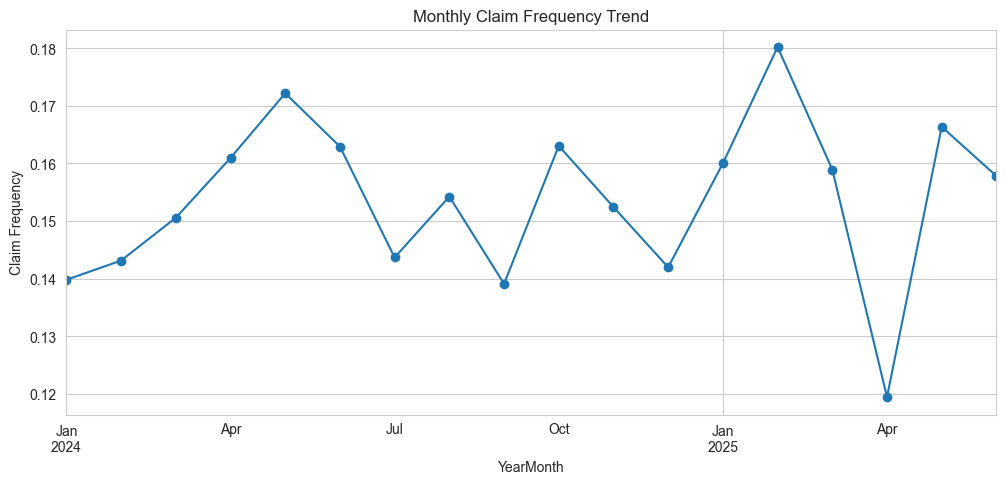

In [27]:
monthly_frequency = (
    df.groupby("YearMonth")
    .agg(
        TotalPolicies=("CustomerID", "count"),
        TotalClaimsMade=("Claimed", "sum")
    )
)

monthly_frequency["ClaimFrequency"] = (
    monthly_frequency["TotalClaimsMade"]
    / monthly_frequency["TotalPolicies"]
)

monthly_frequency["ClaimFrequency"].plot(
    figsize=(12, 5),
    marker="o",
    title="Monthly Claim Frequency Trend"
)

plt.ylabel("Claim Frequency")
plt.grid(True)
plt.show()

## Interpretation of Monthly Claim Frequency Trend

This line chart tracks the **Claim Frequency** (typically calculated as the number of claims divided by the number of active policies) over an 18-month timeline from January 2024 through mid-2025. 

### Key Insights from the Trend Data

* **Cyclical and Seasonal Volatility:** The metric is highly dynamic, fluctuating within a bounded range between **0.12 (12%)** and **0.18 (18%)**. This pattern points to seasonal driving behaviors, weather changes, or renewal periods that cyclically affect accident rates.
* **The 2024 Mid-Year Peaks:** In 2024, frequency builds steadily through the spring, peaking around May at approximately **0.172**. It drops during the summer, spikes briefly in October (**~0.163**), and then drops again heading into the winter holidays.
* **The All-Time High (Early 2025):** The dataset records its maximum claim frequency peak in **February 2025**, spiking up to **0.18**. This sharp rise indicates a highly volatile month with a high volume of incidents relative to active policy counts.
* **The Dramatic Correction:** Immediately following the February peak, claim frequency drops sharply to an all-time low of **0.12** in **April 2025**. This directly correlates with the "Strongest Margin Performance" observed in your monthly amount trend plot, confirming that April 2025 was exceptionally profitable because very few policyholders filed claims.

# Overall EDA Summary and Business Insights

This exploratory data analysis (EDA) examined data completeness, customer risk profiles, asset attributes, regional variations, and financial performance within the 10,000-policy insurance portfolio. By blending operational metrics like premium structures with risk-indicative metrics like the Loss Ratio, we can extract key profitability drivers and areas of strategic concern.

---

## Key Business Insights

### 1. Portfolio Profitability & Structure
* **Healthy Aggregate Margin:** At an aggregate portfolio level, the insurance operation is highly sustainable, maintaining an overall **Loss Ratio of 52.82%**. For every monetary unit collected in premiums, approximately 0.53 units are paid out in claims, leaving a robust baseline to cover operational overhead, reserves, and corporate profit.
* **The Insurance Subsidization Effect:** The baseline profitability is driven by an asymmetric data architecture common to insurance. The median claim amount across the portfolio sits at **0**, demonstrating that more than half of the policyholders generate clean, incident-free premium revenue. This massive base of profitable customers effectively subsidizes a small group of high-severity loss events where claims push up to extreme maximums exceeding **49,000**.

### 2. Underwriting and Risk Segmentation
* **Bimodal Premium Tiers:** Total premiums span from roughly 951 to over 5,105, with an average annual premium of **2,488**. Premium structures exhibit clear tiering, sorting customers into standard consumer brackets and higher-premium segments to reflect higher risks.
* **Expanding High-End Volatility:** As premium sizes step into upper brackets (above 4,000), individual claims widen significantly into a severe risk envelope. Policies inside this upper band exhibit severe standalone deficits, with individual customer loss ratios exceeding **400% to 500%**.

### 3. Asset and Geographic Variation
* **Exposure vs. Incident Volatility:** Vehicle valuations are highly diverse, spanning from 5,022 to nearly 135,000. High-volume manufactures like Toyota dominate aggregate portfolio exposure (exposure volume). However, premium luxury makes and heavy-duty utility segments (such as the Mercedes E-Class, BMW 5 Series, or Toyota Land Cruiser) inject severe, incident-level financial volatility into the portfolio due to high specialized repair and parts replacement costs.
* **Geographic Imbalances:** Underwriting risk varies significantly across geographical domains. While regions like Amhara represent high-margin havens operating at an optimal low loss ratio (~48%), highly volatile zones like the Somali region exhibit significantly higher loss ratios (~61%), indicating an adverse regional risk leak where claims consume an outsized portion of premium income.

### 4. Temporal Trends & Frequency Volatility
* **Jagged Claim Frequency cycles:** While monthly premium collections stay range-bound and stable (between 1.2M and 1.6M), claim frequency fluctuates sharply between **12% and 18%**. 
* **Seasonal Peak and Recoveries:** The portfolio experiences systematic strain during seasonal spikes, reaching an all-time frequency high of **18% in February 2025**. However, it displays excellent restorative capacity, dropping sharply to an all-time low frequency of **12% in April 2025**, mapping out the most profitable operational window in the portfolio's timeline.


# Key Business Insights

## 1. Claims Are Highly Concentrated Among a Small Group of Policyholders

The claims distribution is extremely right-skewed, with the majority of policyholders generating no claims while a small number of customers account for very large claim amounts. This indicates that overall portfolio performance is heavily influenced by a limited number of high-severity claim events.

## 2. Premium Structure Reflects Distinct Customer Segments

The premium distribution exhibits a bimodal pattern, suggesting the presence of at least two distinct pricing tiers within the portfolio. This indicates that customers are segmented into different risk or coverage categories, resulting in substantially different premium levels.

## 3. Vehicle Type Is a Strong Risk Indicator

Luxury vehicles recorded the highest loss ratio among all vehicle categories. This suggests that claims associated with luxury vehicles consume a significantly larger proportion of collected premiums, likely due to expensive repairs, specialized parts, and higher replacement costs.

## 4. Geographic Differences Exist in Portfolio Performance

Loss ratio analysis across provinces revealed measurable differences in profitability. Some regions consistently generate higher claim costs relative to premiums collected, highlighting the importance of geographic factors in insurance pricing and underwriting decisions.

## 5. Vehicle Make Influences Portfolio Exposure

Toyota generated the highest total claim volume in the portfolio. However, this appears to be primarily driven by market exposure and policy volume rather than unusually high individual claim severity.

## 6. Vehicle Model Influences Claim Severity

Models such as the Mercedes-Benz E-Class, BMW 5 Series, and Toyota Land Cruiser recorded the highest average claim amounts. These vehicles represent higher-severity risks due to their elevated repair and replacement costs.

## 7. Premium and Claims Show Positive Association

The relationship between TotalPremium and TotalClaims indicates that policies generating higher premiums also tend to exhibit greater claim variability and larger potential losses. This suggests that pricing mechanisms are partially aligned with underlying risk exposure.

## 8. Portfolio Profitability Remains Positive Overall

The average underwriting margin remains positive, while the average loss ratio is approximately 53%. This indicates that, overall, premium income exceeds claim payouts, although profitability varies substantially across customer segments and vehicle categories.

---

## Conclusion

The exploratory data analysis confirms that the insurance dataset is in immaculate condition with **0% missing values and zero duplicate records**, making it an ideal candidate for predictive modeling. 

From a business stance, the portfolio is structurally sound and performing profitably at an aggregate 52.82% loss ratio. However, this overall success masks clear pockets of margin erosion. Financial performance is currently dragged down by an unsustainable **84% loss ratio in the Luxury vehicle category** and an elevated **61% loss ratio in the Somali region**. Conversely, profitability is firmly anchored by highly common, low-severity economy vehicles (Sedans/Hatchbacks at a 40–42% loss ratio) and favorable geographic performance in Amhara (48% loss ratio). 

These findings successfully complete the EDA phase, pinpointing exactly where premium pricing, regional loading factors, and risk selection criteria need to be adjusted. The distinct asset clusters, demographic indicators, and temporal cycles uncovered here will serve as the exact foundational features for subsequent statistical testing and machine learning tasks.